In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Dataset and model architecture

# Custom Dataset Class
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))


    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        original_size = image.shape[1], image.shape[0]  # (W, H)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()
            mask = (mask > 0.5).float()

        return image, mask, original_size

# UNet Model Architecture
class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet, self).__init__()

        def double_conv(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout(0.2), # Dropout
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.dconv_down1 = double_conv(n_channels, 64)
        self.dconv_down2 = double_conv(64, 128)
        self.dconv_down3 = double_conv(128, 256)
        self.dconv_down4 = double_conv(256, 512)
        self.dconv_bottom = double_conv(512, 1024)

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dconv_up4 = double_conv(512 + 1024, 512)
        self.dconv_up3 = double_conv(256 + 512, 256)
        self.dconv_up2 = double_conv(128 + 256, 128)
        self.dconv_up1 = double_conv(64 + 128, 64)

        self.conv_last = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)

        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)

        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)

        conv4 = self.dconv_down4(x)
        x = self.maxpool(conv4)


        x = self.dconv_bottom(x)

        x = self.upsample(x)
        x = torch.cat([x, conv4], dim=1)
        x = self.dconv_up4(x)

        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)

        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)

        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)

        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

In [ ]:
## Transformations

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [ ]:
train_transform = A.Compose([
    A.Resize(256, 256),

    # Spatial augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),

    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),

    # Color & contrast augmentations
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.CLAHE(clip_limit=2.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20),
    ], p=0.5),

    # Blur or noise
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MotionBlur(blur_limit=(3, 5)),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5))
    ], p=0.3),

    # Distortion (fixed ElasticTransform)
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),

    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [ ]:
# Dice Loss and Metric
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        return 1 - dice

def dice_score(preds, targets, smooth=1e-7):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    targets = targets.float()

    intersection = (preds * targets).sum()
    return (2.*intersection + smooth)/(preds.sum() + targets.sum() + smooth)

In [ ]:
def iou_score(preds, targets, threshold=0.5, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) - intersection
    iou = (intersection + smooth) / (union + smooth)

    return iou.mean().item()

In [ ]:
def cross_correlation_score(preds, targets, eps=1e-8):

    preds = torch.sigmoid(preds)
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    # Normalize
    preds_mean = preds.mean(dim=1, keepdim=True)
    targets_mean = targets.mean(dim=1, keepdim=True)

    preds_centered = preds - preds_mean
    targets_centered = targets - targets_mean

    numerator = (preds_centered * targets_centered).sum(dim=1)
    denominator = torch.sqrt((preds_centered ** 2).sum(dim=1) * (targets_centered ** 2).sum(dim=1)) + eps

    correlation = numerator / denominator
    return correlation.mean().item()


In [ ]:
#Hyperparameters
EPOCHS = 300
BATCH_SIZE = 8
LEARNING_RATE = 1e-4



# Training Setup
def train_unet():
    # Transforms
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])

    # Dataset and DataLoader
    train_dataset = SegmentationDataset(
        image_dir='/content/drive/MyDrive/Colab Notebooks/content/current_dataset/train_data',
        mask_dir='/content/drive/MyDrive/Colab Notebooks/content/current_dataset/train_masks',
        transform=train_transform
    )

    val_dataset = SegmentationDataset(
        image_dir='/content/drive/MyDrive/Colab Notebooks/content/current_dataset/val_data',
        mask_dir='/content/drive/MyDrive/Colab Notebooks/content/current_dataset/val_masks',
        transform=val_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #Batch size
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, Optimizer, Loss
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = UNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE) #Learning rate
    criterion = DiceLoss()

    # Training Loop
    best_val_dice = 0
    for epoch in range(EPOCHS): #epochs
        model.train()
        for images, masks, original_size in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_dice = 0
        val_iou = 0.0
        val_corr = 0.0
        with torch.no_grad():
            for images, masks, original_size in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)
                val_dice += dice_score(outputs, masks)
                val_iou += iou_score(outputs, masks)
                val_corr += cross_correlation_score(outputs, masks)

        val_dice /= len(val_loader)
        val_iou /= len(val_loader)
        val_corr /= len(val_loader)
        scheduler.step(val_dice)

        current_lr = scheduler.optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}, Val Dice: {val_dice:.4f}, Val IoU: {val_iou:.4f}, Cross-Corr: {val_corr:.4f}, LR: {current_lr:.10f}')


        # Save best model
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'best_val_dice': best_val_dice
}, '/content/drive/MyDrive/Colab Notebooks/content/current_dataset/best_model.pt')


    print(f'Training Complete. Best Val Dice: {best_val_dice:.4f}')


In [ ]:
#Plotting fxn

def visualize_predictions(dataset, model, device, num_samples=3):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=True)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(indices):
        image, mask, original_size = dataset[idx]  # image and mask are tensors; original_size is (W, H)
        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_mask = torch.sigmoid(model(image_tensor))
            pred_mask = (pred_mask > 0.5).float()

        # Resize prediction to original size
        pred_mask_resized = F.interpolate(
            pred_mask, size=(original_size[1], original_size[0]), mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()

        # Resize true mask to original size
        mask_np = F.interpolate(mask.unsqueeze(0), size=(original_size[1], original_size[0]), mode='nearest') \
                     .squeeze().cpu().numpy()

        # Resize image back to original size
        image_np = image.cpu().numpy()
        image_np = np.transpose(image_np, (1, 2, 0))  # CHW -> HWC
        image_np = (image_np * 255).astype(np.uint8)  # [0,1] → [0,255]
        image_resized = Image.fromarray(image_np).resize(original_size, resample=Image.BILINEAR)
        image_np_resized = np.array(image_resized)

        # Plot resized original image
        axes[i, 0].imshow(image_np_resized)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis('off')

        # Plot true mask
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title("True Mask (Resized)")
        axes[i, 1].axis('off')

        # Plot predicted mask
        axes[i, 2].imshow(pred_mask_resized, cmap='gray')
        axes[i, 2].set_title("Predicted Mask (Resized)")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

In [ ]:
# Train model

if __name__ == '__main__':
    train_unet()

Epoch 1, Val Dice: 0.0000, Val IoU: 0.0000, Cross-Corr: 0.1000, LR: 0.0001000000
Epoch 2, Val Dice: 0.0000, Val IoU: 0.0000, Cross-Corr: 0.1230, LR: 0.0001000000
Epoch 3, Val Dice: 0.0000, Val IoU: 0.0000, Cross-Corr: 0.2477, LR: 0.0001000000
Epoch 4, Val Dice: 0.0000, Val IoU: 0.0000, Cross-Corr: 0.2357, LR: 0.0001000000
Epoch 5, Val Dice: 0.1214, Val IoU: 0.0712, Cross-Corr: 0.4146, LR: 0.0001000000
Epoch 6, Val Dice: 0.3827, Val IoU: 0.2443, Cross-Corr: 0.4776, LR: 0.0001000000
Epoch 7, Val Dice: 0.1590, Val IoU: 0.0886, Cross-Corr: 0.3298, LR: 0.0001000000
Epoch 8, Val Dice: 0.1321, Val IoU: 0.0721, Cross-Corr: 0.3043, LR: 0.0001000000
Epoch 9, Val Dice: 0.1385, Val IoU: 0.0747, Cross-Corr: 0.2954, LR: 0.0001000000
Epoch 10, Val Dice: 0.0807, Val IoU: 0.0428, Cross-Corr: 0.2388, LR: 0.0001000000
Epoch 11, Val Dice: 0.1089, Val IoU: 0.0577, Cross-Corr: 0.2587, LR: 0.0001000000
Epoch 12, Val Dice: 0.0949, Val IoU: 0.0507, Cross-Corr: 0.2418, LR: 0.0001000000
Epoch 13, Val Dice: 0.139

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNet().to(device)
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/content/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_dataset = SegmentationDataset(
    image_dir='/content/drive/MyDrive/Colab Notebooks/content/current_dataset/val_data',
    mask_dir='/content/drive/MyDrive/Colab Notebooks/content/current_dataset/val_masks',
    transform=val_transform
)

visualize_predictions(val_dataset, model, device, num_samples=6)

NameError: name 'UNet' is not defined

In [ ]:
def load_model(checkpoint_path, model, optimizer=None):
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with best_val_dice = {checkpoint['best_val_dice']:.4f}")
    return model


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model = load_model('/content/drive/MyDrive/Colab Notebooks/content/current_dataset/best_model_alldata.pt', model, optimizer)


Loaded model from epoch 270 with best_val_dice = 0.8535


In [ ]:
def predict_single_image(image_path, model, transform, device, threshold=0.5):
    # Load and preprocess image
    image = np.array(Image.open(image_path).convert("RGB"))
    original_size = image.shape[:2]  # (H, W)

    augmented = transform(image=image)
    input_tensor = augmented['image'].unsqueeze(0).to(device)  # (1, C, H, W)

    # Inference
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(input_tensor))
        pred_mask = (pred > threshold).float().squeeze().cpu().numpy()

    # Calculate area (number of positive pixels)
    area = np.sum(pred_mask)  # Count of 1s

    # Resize predicted mask to original image size for display
    pred_mask_resized = Image.fromarray((pred_mask * 255).astype(np.uint8)) \
                            .resize((original_size[1], original_size[0]), resample=Image.BILINEAR)

    # Show results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask_resized, cmap='gray')
    plt.title(f"Predicted Mask\nArea: {int(area)} pixels")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return area  # Optional: return area for logging or further use


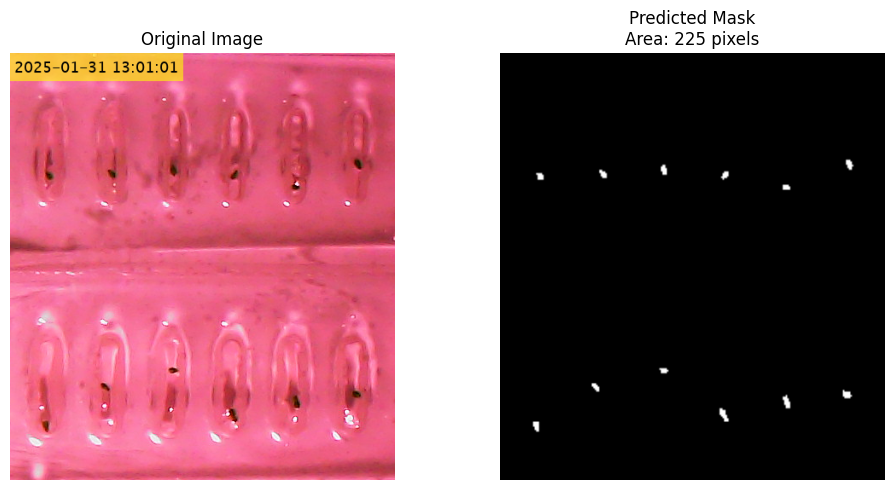

Predicted area: 225 pixels


In [ ]:
image_path = '/content/drive/MyDrive/Colab Notebooks/content/current_dataset/unseen_data/img_0.png'
area = predict_single_image(image_path, model, val_transform, device)
print(f"Predicted area: {int(area)} pixels")


In [ ]:
def predict_and_visualize_separately(image_path, model, transform, device, threshold=0.5, min_area=15):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    import scipy.ndimage as ndi

    # Load and preprocess image
    image = np.array(Image.open(image_path).convert("RGB"))
    original_size = image.shape[:2]  # (H, W)

    # Apply transform (e.g., resizing and normalization)
    augmented = transform(image=image)
    input_tensor = augmented['image'].unsqueeze(0).to(device)

    # Model inference
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(input_tensor))
        pred = (pred > threshold).float()

    # Resize prediction to original image size
    pred_resized = F.interpolate(pred, size=original_size, mode='bilinear', align_corners=False)
    pred_mask = pred_resized.squeeze().cpu().numpy()

    # Label connected components
    labeled_mask, num_objects = ndi.label(pred_mask)
    object_areas = ndi.sum_labels(pred_mask, labeled_mask, index=np.arange(1, num_objects + 1))

    # Create canvas for drawing
    canvas = np.zeros_like(image)
    object_info = []
    kept_objects = 0

    for obj_id, area in enumerate(object_areas, start=1):
        if area < min_area:
            continue  # Skip small objects

        obj_mask = (labeled_mask == obj_id).astype(np.uint8)

        # Find contours
        contours, _ = cv2.findContours(obj_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        # Draw green contour
        cv2.drawContours(canvas, contours, -1, (0, 255, 0), 2)

        # Compute centroid
        M = cv2.moments(obj_mask)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            kept_objects += 1
            cv2.putText(canvas, str(kept_objects), (cX, cY), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 0, 0), 2)

            object_info.append({'object_id': kept_objects, 'area': int(area)})

    # Plot results
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(canvas)
    plt.title(f"Filtered Annotations: {kept_objects} object(s) ≥ {min_area} px")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return canvas, object_info


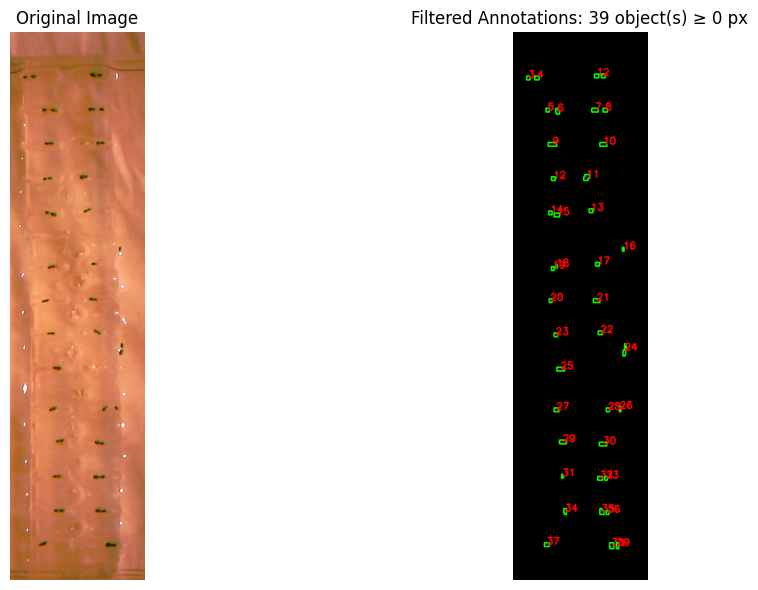

Object 1: 35 pixels
Object 2: 27 pixels
Object 3: 23 pixels
Object 4: 31 pixels
Object 5: 23 pixels
Object 6: 39 pixels
Object 7: 51 pixels
Object 8: 31 pixels
Object 9: 62 pixels
Object 10: 50 pixels
Object 11: 66 pixels
Object 12: 27 pixels
Object 13: 27 pixels
Object 14: 23 pixels
Object 15: 39 pixels
Object 16: 11 pixels
Object 17: 27 pixels
Object 18: 11 pixels
Object 19: 19 pixels
Object 20: 19 pixels
Object 21: 51 pixels
Object 22: 31 pixels
Object 23: 23 pixels
Object 24: 62 pixels
Object 25: 54 pixels
Object 26: 23 pixels
Object 27: 35 pixels
Object 28: 23 pixels
Object 29: 50 pixels
Object 30: 54 pixels
Object 31: 11 pixels
Object 32: 35 pixels
Object 33: 19 pixels
Object 34: 43 pixels
Object 35: 47 pixels
Object 36: 19 pixels
Object 37: 35 pixels
Object 38: 58 pixels
Object 39: 27 pixels


In [ ]:
canvas, objects = predict_and_visualize_separately(
    '/content/drive/MyDrive/Colab Notebooks/content/current_dataset/unseen_data/new_img_105.png',
    model, val_transform, device,
    threshold=0.5, min_area=0  # Set minimum size here
)

for obj in objects:
    print(f"Object {obj['object_id']}: {obj['area']} pixels")


In [ ]:
import cv2
import torch
import numpy as np
from torchvision import transforms
from matplotlib import pyplot as plt
from tqdm import tqdm
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance
import itertools

frame_object_sizes = []  # List of lists: areas per frame
next_object_id = 0
tracked_objects = {}  # object_id: (centroid_x, centroid_y)
tracked_history = []  # [{'frame': i, 'id': id, 'area': area, 'centroid': (x, y)}]
max_distance = 30

# Replace this with your actual model loading
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#model = torch.load('/content/drive/MyDrive/Colab Notebooks/content/current_dataset/best_model_0630.pt', map_location=device)
model.eval()

# Customize to match your model's input format
def preprocess_frame(frame, target_size=(256, 256)):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalize to [0,1]
    img = torch.tensor(img, dtype=torch.float).permute(2, 0, 1).unsqueeze(0)  # (1, C, H, W)
    return img.to(device)

def postprocess_mask(mask_tensor, orig_shape):
    mask_np = mask_tensor.squeeze().cpu().detach().numpy()
    mask_np = (mask_np > 0.5).astype(np.uint8) * 255
    return cv2.resize(mask_np, (orig_shape[1], orig_shape[0]))

video_path = '/content/drive/MyDrive/Colab Notebooks/content/duckweed_25_0504_multiple.avi'
cap = cv2.VideoCapture(video_path)

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('drive/MyDrive/Colab Notebooks/content/segmented_output_new.avi', fourcc, 20.0, (int(cap.get(3)), int(cap.get(4))))

Done. Output saved as 'segmented_output.avi'
Saved tracked object data to tracked_objects.csv


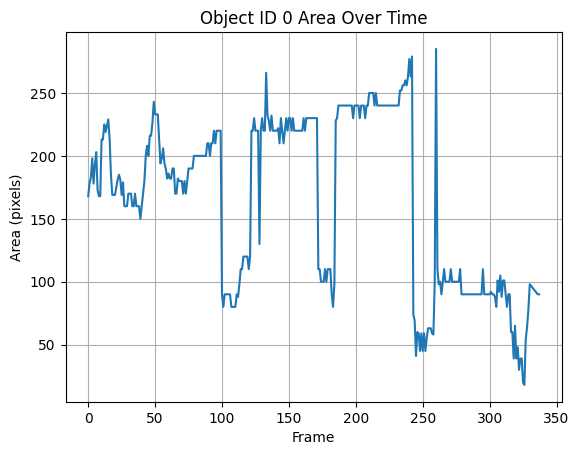

In [ ]:
with torch.no_grad():
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        orig_shape = frame.shape[:2]  # (H, W)
        input_tensor = preprocess_frame(frame)
        output = model(input_tensor)

        # Assume binary mask output
        if output.shape[1] == 1:
            mask = torch.sigmoid(output)[0, 0]
        else:
            mask = torch.softmax(output, dim=1)[0].argmax(0).float()

        mask_resized = postprocess_mask(mask, orig_shape)

        # Extract objects
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_resized)
        curr_objects = {}  # centroid → area

        for i in range(1, num_labels):  # skip background
            c = tuple(centroids[i])  # (x, y)
            a = stats[i, cv2.CC_STAT_AREA]
            curr_objects[c] = a

        # Match current to previous objects
        matched_ids = {}
        used_ids = set()
        for c_curr in curr_objects:
            min_dist = float('inf')
            matched_id = None
            for obj_id, c_prev in tracked_objects.items():
                d = distance.euclidean(c_curr, c_prev)
                if d < min_dist and d < max_distance and obj_id not in used_ids:
                    min_dist = d
                    matched_id = obj_id

            if matched_id is not None:
                matched_ids[c_curr] = matched_id
                used_ids.add(matched_id)
                tracked_objects[matched_id] = c_curr  # update position
            else:
                # Assign new ID
                matched_ids[c_curr] = next_object_id
                tracked_objects[next_object_id] = c_curr
                next_object_id += 1

        # Save tracking info
        for c, obj_id in matched_ids.items():
            area = curr_objects[c]
            tracked_history.append({
                'frame': int(cap.get(cv2.CAP_PROP_POS_FRAMES)) - 1,
                'id': obj_id,
                'area': area,
                'centroid_x': c[0],
                'centroid_y': c[1],
            })

        # Optional: Overlay mask on original
        overlay = frame.copy()
        overlay[mask_resized > 0] = [0, 255, 0]  # Green mask

        out.write(overlay)

cap.release()
out.release()
print("Done. Output saved as 'segmented_output.avi'")
# Flatten to one row per object per frame
data = []
for i, areas in enumerate(frame_object_sizes):
    for j, area in enumerate(areas):
        data.append({'frame': i, 'object_id': j, 'area': area})

df_tracking = pd.DataFrame(tracked_history)
df_tracking.to_csv('drive/MyDrive/Colab Notebooks/content/tracked_objects.csv', index=False)
print("Saved tracked object data to tracked_objects.csv")

# Optional: plot area of object ID 0 over time
obj0 = df_tracking[df_tracking['id'] == 0]
plt.plot(obj0['frame'], obj0['area'])
plt.xlabel('Frame')
plt.ylabel('Area (pixels)')
plt.title('Object ID 0 Area Over Time')
plt.grid()
plt.show()


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from skimage import measure
from skimage.measure import regionprops_table
from skimage.color import label2rgb
from skimage.transform import resize

def analyze_single_image(frame, model, device='cuda'):

    model.eval()

    original_shape = frame.shape[:2]  # (H, W)
    input_size = (256, 256)

    # Preprocess image
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(input_size),
    ])
    input_tensor = transform(frame).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()

    # Threshold
    binary_mask_small = (pred_mask > 0.5).astype(np.uint8)

    # Resize predicted mask back to original image shape
    binary_mask = resize(binary_mask_small, original_shape, preserve_range=True)
    binary_mask = (binary_mask > 0.5).astype(np.uint8)

    # Label connected regions
    labeled_mask = measure.label(binary_mask)

    # Get region properties
    props = regionprops_table(
        labeled_mask,
        properties=['label', 'area', 'perimeter', 'bbox', 'centroid']
    )

    # Visualization setup
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Original image
    axes[0].imshow(frame)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Mask with labels
    overlay = label2rgb(labeled_mask, image=frame, bg_label=0)
    axes[1].imshow(overlay)
    axes[1].set_title("Predicted Mask with Labels")

    for region in measure.regionprops(labeled_mask):
        minr, minc, maxr, maxc = region.bbox
        cy, cx = region.centroid

        # Draw bounding box
        axes[1].plot(
            [minc, maxc, maxc, minc, minc],
            [minr, minr, maxr, maxr, minr],
            color='red', linewidth=1.2
        )

        # Smaller, less intrusive labels
        axes[1].text(
            cx, cy, str(region.label),
            color='yellow', fontsize=6, ha='center', va='center',
            bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1)
        )

    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    return props


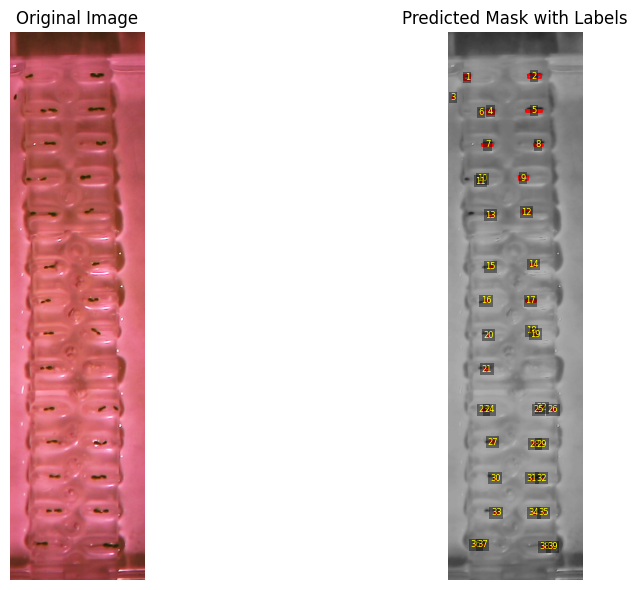

    label   area  perimeter  bbox-0  bbox-1  bbox-2  bbox-3  centroid-0  \
0       1   54.0  32.485281      80      30      88      42   84.092593   
1       2  100.0  54.000000      80     149      84     174   81.500000   
2       3   10.0   8.828427     120       9     124      12  121.500000   
3       4   71.0  35.656854     144      73     152      86  147.183099   
4       5  120.0  64.000000     144     146     148     176  145.500000   
5       6   22.0  14.828427     148      59     152      65  149.500000   
6       7   84.0  46.000000     208      64     212      85  209.500000   
7       8   72.0  40.000000     208     160     212     178  209.500000   
8       9  119.0  52.485281     268     132     276     150  271.899160   
9      10    6.0   6.414214     272      64     276      66  273.500000   
10     11    6.0   6.414214     276      60     280      62  277.500000   
11     12   62.0  38.828427     332     140     340     155  335.693548   
12     13   48.0  28.0000

In [ ]:
# For a single image
frame = cv2.imread("/content/drive/MyDrive/Colab Notebooks/content/current_dataset/unseen_data/new_img_222.png")
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
region_info = analyze_single_image(frame_rgb, model)
print(pd.DataFrame(region_info))

In [ ]:
import cv2
import torch
import numpy as np
import pandas as pd
from torchvision import transforms
from skimage import measure
from skimage.measure import regionprops_table
from skimage.color import label2rgb
from skimage.transform import resize
import matplotlib.pyplot as plt

def analyze_video_with_model_and_visual_output(video_path, model, output_path='output_with_masks.avi', device='cuda'):
    model.eval()

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_size = (width * 2, height)  # side-by-side

    # Video writer
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out_video = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),
    ])

    all_data = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        original_shape = frame_rgb.shape[:2]

        # Predict mask
        input_tensor = transform(frame_rgb).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
        binary_mask_small = (pred_mask > 0.5).astype(np.uint8)

        # Resize mask to original shape
        binary_mask = resize(binary_mask_small, original_shape, preserve_range=True)
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

        # Label and measure
        labeled_mask = measure.label(binary_mask)
        props = regionprops_table(
            labeled_mask,
            properties=['label', 'area', 'perimeter', 'bbox', 'centroid']
        )

        # Store data
        df = pd.DataFrame(props)
        df['frame'] = frame_idx
        all_data.append(df)

        # Visualization
        overlay = label2rgb(labeled_mask, image=frame_rgb, bg_label=0)
        overlay = (overlay * 255).astype(np.uint8)

        # Draw boxes and labels
        for region in measure.regionprops(labeled_mask):
            minr, minc, maxr, maxc = region.bbox
            cy, cx = region.centroid

            # Bounding box
            cv2.rectangle(overlay, (minc, minr), (maxc, maxr), (255, 0, 0), 1)

            # Label
            cv2.putText(
                overlay, str(region.label), (int(cx), int(cy)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1, cv2.LINE_AA
            )

        # Convert RGB images back to BGR for OpenCV
        original_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
        overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)

        # Combine side-by-side
        combined = np.concatenate((original_bgr, overlay_bgr), axis=1)
        out_video.write(combined)
        frame_idx += 1

    cap.release()
    out_video.release()

    final_df = pd.concat(all_data, ignore_index=True)
    return final_df


In [ ]:
# Run on video
stats_df = analyze_video_with_model_and_visual_output(
    video_path="/content/drive/MyDrive/Colab Notebooks/content/duckweed_25_0504_multiple.avi",
    model=model,
    output_path="/content/drive/MyDrive/Colab Notebooks/content/test_output_vid.avi",
    device="cuda"
)

# Save stats
#stats_df.to_csv("region_stats.csv", index=False)

In [ ]:
def convert_and_display_video(avi_path, mp4_path="/content/output.mp4", width=640):
    import os
    import subprocess
    from IPython.display import HTML
    from base64 import b64encode

    # Check if .avi file exists
    if not os.path.exists(avi_path):
        raise FileNotFoundError(f"❌ .avi file not found: {avi_path}")

    # Install ffmpeg if needed
    if not os.path.exists("/usr/bin/ffmpeg"):
        print("🔧 Installing ffmpeg...")
        subprocess.run(["apt-get", "install", "-y", "ffmpeg"], check=True)

    # Convert .avi to .mp4
    print(f"🎞️ Converting {avi_path} to {mp4_path}...")
    result = subprocess.run(
        ["ffmpeg", "-y", "-i", avi_path, "-vcodec", "libx264", "-crf", "23", mp4_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    # Check for errors in conversion
    if result.returncode != 0:
        print("❌ ffmpeg error:")
        print(result.stderr.decode())
        raise RuntimeError("ffmpeg failed to convert the video.")

    # Check if .mp4 was created
    if not os.path.exists(mp4_path):
        raise FileNotFoundError(f"❌ .mp4 file was not created at {mp4_path}")

    # Load and encode .mp4
    mp4 = open(mp4_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    # Display video
    return HTML(f"""
    <video width={width} controls>
        <source src="{data_url}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """)



In [ ]:
video_path="/content/drive/MyDrive/Colab Notebooks/content/test_output_vid.avi"
output_path="/content/drive/MyDrive/Colab Notebooks/content/testing_output_vid.mp4"
convert_and_display_video(video_path,output_path)

🎞️ Converting /content/drive/MyDrive/Colab Notebooks/content/test_output_vid.avi to /content/drive/MyDrive/Colab Notebooks/content/testing_output_vid.mp4...


In [ ]:
import cv2
import numpy as np
from btrack import BTrackConfig, BTrack
from btrack.constants import BayesianUpdates
from btrack.dataio import objects_to_array
from skimage.measure import regionprops, label

def track_duckweed_with_btrack(video_path, model, config_path='btrack_config.json'):
    """
    Tracks duckweed growth in a .avi video using btrack and a U-Net segmentation model.

    Parameters:
        video_path (str): Path to the input .avi video.
        model (torch.nn.Module): Trained U-Net model.
        config_path (str): Path to btrack config JSON file.

    Returns:
        tracker: btrack.BayesianTracker object after tracking.
    """
    # Set up video reader
    cap = cv2.VideoCapture(video_path)
    tracker = BTrack(config=config_path)

    tracker.configure(BayesianUpdates.PREDICT)
    tracker.set_update_method(BayesianUpdates.EKF)
    tracker.set_volume((0, 0, 0, 512, 512, 0))  # Update based on your image size

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale if needed
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        img = gray.astype(np.float32) / 255.0
        img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

        # Segment with model
        with torch.no_grad():
            mask_pred = model(img).squeeze().cpu().numpy() > 0.5  # Binary mask

        # Get centroids from the mask
        labeled_mask = label(mask_pred)
        regions = regionprops(labeled_mask)

        objects = []
        for region in regions:
            y, x = region.centroid
            obj = {
                'ID': -1,
                't': frame_idx,
                'x': x,
                'y': y,
                'z': 0,
                'label': 1
            }
            objects.append(obj)

        tracker.append(objects)
        frame_idx += 1

    cap.release()
    tracker.track_interactive(step_size=100)
    tracker.optimize()
    return tracker

ImportError: cannot import name 'BTrackConfig' from 'btrack' (/usr/local/lib/python3.11/dist-packages/btrack/__init__.py)